In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input 
from tensorflow.keras.models import Sequential




In [19]:
data=pd.read_csv("94_character_TMNIST.csv")
data.head()




,names,labels,1,2,3,4,5,6,7,8,...,775,776,777,778,779,780,781,782,783,784
0,Salsa-Regular,6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,MouseMemoirs-Regular,D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Creepster-Regular,f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SeoulNamsan-Light,/,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,HachiMaruPop-Regular,F,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
num_classes= data["labels"].nunique()
# print the number of unique classes in the "labels" column to define the number of neurons in the output layer of the ANN model
print(num_classes)
print(data["labels"].unique())



94
<StringArray>
['6', 'D', 'f', '/', 'F', 'x', 'J', '8', 'H', 'k', '@', '1', '=', 'g', ')',
 '2', 'd', '^', '3', 't', '#', '.', '4', 'o', '"', 'y', 'A', 'u', 'G', '-',
 'm', 'W', '&', 'c', '9', 'N', ']', 'P', 'X', '|', '}', 'h', '7', 'j', '5',
 '>', '?', 'b', '*', 'w', 'l', '0', '$', 'I', 'Y', '%', ':', 'T', 'K', 'E',
 '<', 'V', '{', 'M', 'S', 'a', 'i', 'r', ''', 'p', ';', '[', '+', 'e', 'U',
 '(', 's', '~', ',', 'C', 'q', '_', 'n', 'B', 'z', 'v', 'O', 'R', '`', 'Z',
 'Q', 'L', '!', '\']
Length: 94, dtype: str


In [7]:
# to drop names and labels when we use axis=1 to drop columns instead of rows 
x= data.drop(["names","labels"],axis=1)
y=data["labels"]

In [8]:
encoder = LabelEncoder()
target_encoded= encoder.fit_transform(y)



In [9]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,target_encoded,test_size=0.2,random_state=42)


normalization using min_max 

In [10]:
x_train=x_train /255.0
x_test=x_test /255.0

In [11]:
model=Sequential([
    Input(shape=(784,)),
    Dense(512,activation="relu"),
    Dense(128,activation="relu"),
    Dense(32,activation="relu"),
    Dense(num_classes,activation="softmax")
])


In [12]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [13]:
r = model.fit(x_train,y_train,validation_data=(x_test, y_test),epochs=20,batch_size=128)

Epoch 1/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7899 - loss: 0.7966 - val_accuracy: 0.8523 - val_loss: 0.4922
Epoch 2/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8667 - loss: 0.4323 - val_accuracy: 0.8716 - val_loss: 0.4180
Epoch 3/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8823 - loss: 0.3645 - val_accuracy: 0.8753 - val_loss: 0.3927
Epoch 4/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8933 - loss: 0.3232 - val_accuracy: 0.8855 - val_loss: 0.3646
Epoch 5/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9022 - loss: 0.2901 - val_accuracy: 0.8922 - val_loss: 0.3453
Epoch 6/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9102 - loss: 0.2653 - val_accuracy: 0.8957 - val_loss: 0.3398
Epoch 7/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9161 - loss: 0.2430 - val_accuracy: 0.8943 - val_loss: 0.3455
Epoch 8/20
1714/1714 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9212 - loss: 

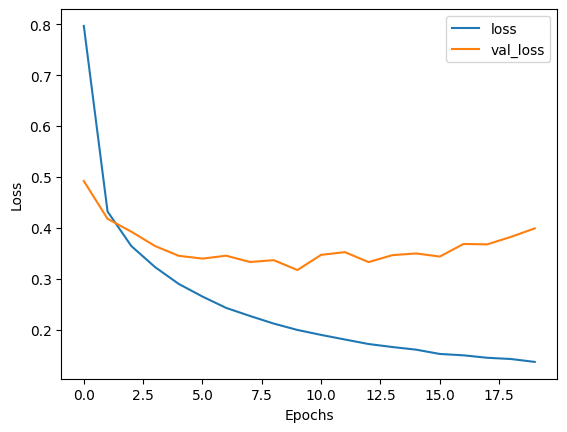

In [14]:
plt.plot(r.history["loss"],label="loss")
plt.plot(r.history["val_loss"],label="val_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [15]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 94)             │         3,102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,444 (5.43 MB)

 Trainable params: 474,814 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 949,630 (3.62 MB)

None


In [16]:
print(model.evaluate(x_test,y_test))

1714/1714 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9105 - loss: 0.3991
[0.39911743998527527, 0.9105237126350403]


save model 

In [17]:
model.save("tmnist_model.keras")

In [18]:
import joblib
joblib.dump(encoder,"tmnist_encoder.joblib")



['tmnist_encoder.joblib']